## Экстрактим фичи из картинок при помощи [SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)

In [1]:
import sys
sys.path.append('../..')

%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split

from src.model.feature_extraction import extract_hog_features


In [3]:
path_to_dataset = Path("../../data/01_raw/sneakers-dataset")

In [4]:
train = pd.read_csv('../../data/01_raw/train_images.csv')
test = pd.read_csv('../../data/01_raw/test_images.csv')

In [5]:
train.set_index('path', inplace=True)
test.set_index('path', inplace=True)

In [6]:
import cv2 as cv

img_path = 'nike_dunk_low/0002.jpg'
img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
img

array([[245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       ...,
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245]], shape=(140, 140), dtype=uint8)

In [7]:
pd.Series(extract_hog_features(img)).describe()

count    1764.000000
mean        0.073660
std         0.122035
min         0.000000
25%         0.000000
50%         0.005362
75%         0.106010
max         0.820708
dtype: float64

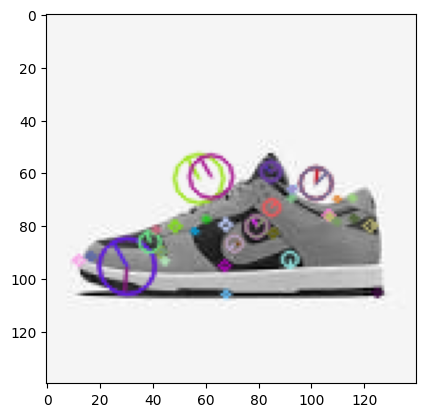

In [8]:
# Для каждого изображения в датафрейме считаем SIFT
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)
img_with_keypoints = cv.drawKeypoints(img, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_with_keypoints)

In [9]:
feature_df = []
for img_path in train.index:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    feature_df.append(descriptors)
feature_df = pd.concat(feature_df)
feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,0.0,0.0,0.0,0.0,79.0,144.0,1.0,0.0,102.0,22.0,...,13.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,nike_air_force_1_high/0036.jpg
1,0.0,1.0,25.0,14.0,1.0,0.0,0.0,0.0,0.0,11.0,...,36.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,nike_air_force_1_high/0036.jpg
2,36.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,137.0,2.0,...,17.0,9.0,36.0,3.0,7.0,74.0,26.0,0.0,0.0,nike_air_force_1_high/0036.jpg
3,19.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,60.0,0.0,...,1.0,75.0,18.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_high/0036.jpg
4,13.0,2.0,2.0,7.0,1.0,0.0,2.0,26.0,172.0,4.0,...,9.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_high/0036.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,4.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,150.0,53.0,...,88.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_low/0137.jpg
38,35.0,92.0,0.0,0.0,0.0,0.0,0.0,2.0,87.0,156.0,...,156.0,16.0,1.0,0.0,0.0,0.0,0.0,1.0,11.0,nike_air_force_1_low/0137.jpg
39,0.0,0.0,2.0,19.0,15.0,57.0,30.0,0.0,138.0,16.0,...,7.0,78.0,36.0,0.0,0.0,0.0,0.0,0.0,3.0,nike_air_force_1_low/0137.jpg
40,5.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,113.0,1.0,...,65.0,59.0,1.0,0.0,0.0,0.0,0.0,0.0,7.0,nike_air_force_1_low/0137.jpg


In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feature_df[list(range(128))] = scaler.fit_transform(feature_df[list(range(128))])
n_feats = 200
clustering = KMeans(n_feats)
clustering.fit(feature_df[list(range(128))])
feature_df['cluster_feat'] = clustering.predict(feature_df[list(range(128))]).astype(str)

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneake

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.274s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 3.063638


/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-

[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.307098
[t-SNE] KL divergence after 1000 iterations: 2.642727


/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/3664400311.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/3664400311.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])


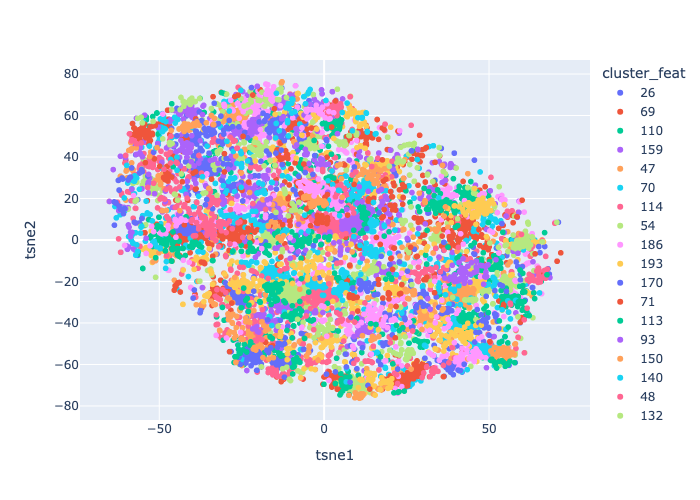

In [11]:
from sklearn.manifold import TSNE
import plotly.express as px
from IPython.display import Image, display


# Assume X is your high-dimensional data matrix and y are labels or target classes
tsne = TSNE(n_components=2, random_state=123, verbose=1)
sample_df = feature_df.sample(10000, random_state=0)
sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
fig = px.scatter(sample_df, x='tsne1', y='tsne2', color='cluster_feat')
display(Image(fig.to_image('png')))


In [12]:
test_feature_df = []
for img_path in test.index:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    test_feature_df.append(descriptors)
test_feature_df = pd.concat(test_feature_df)
test_feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,33.0,19.0,7.0,3.0,19.0,16.0,27.0,22.0,4.0,3.0,...,37.0,0.0,1.0,0.0,0.0,30.0,9.0,0.0,1.0,adidas_forum_low/0026.jpg
1,1.0,7.0,6.0,0.0,4.0,39.0,27.0,3.0,48.0,1.0,...,4.0,54.0,1.0,1.0,2.0,1.0,1.0,2.0,3.0,adidas_forum_low/0026.jpg
2,0.0,0.0,154.0,154.0,0.0,0.0,0.0,1.0,2.0,1.0,...,10.0,2.0,4.0,18.0,13.0,6.0,5.0,38.0,62.0,adidas_forum_low/0026.jpg
3,148.0,23.0,0.0,0.0,0.0,0.0,24.0,38.0,148.0,42.0,...,14.0,7.0,11.0,8.0,4.0,20.0,1.0,0.0,3.0,adidas_forum_low/0026.jpg
4,0.0,3.0,34.0,8.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,35.0,93.0,3.0,0.0,0.0,0.0,0.0,0.0,adidas_forum_low/0026.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,1.0,0.0,0.0,0.0,6.0,32.0,42.0,30.0,7.0,0.0,...,19.0,5.0,0.0,0.0,0.0,0.0,0.0,6.0,15.0,nike_cortez/0130.jpg
13,0.0,98.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0,...,131.0,47.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,nike_cortez/0130.jpg
14,0.0,1.0,31.0,141.0,7.0,0.0,0.0,0.0,89.0,67.0,...,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nike_cortez/0130.jpg
15,43.0,105.0,34.0,5.0,0.0,0.0,0.0,0.0,11.0,122.0,...,36.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,nike_cortez/0130.jpg


In [13]:
test_feature_df[list(range(128))] = scaler.transform(test_feature_df[list(range(128))])
test_feature_df['cluster_feat'] = clustering.predict(test_feature_df[list(range(128))]).astype(str)

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/89987943.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [14]:
train[list(range(n_feats))] = 0
for i, row in tqdm(feature_df.iterrows()):
    train.loc[row['path'], int(row['cluster_feat'])] += 1
train

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.conca

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_force_1_high/0036.jpg,nike_air_force_1_high,0,0,0,0,0,0,0,0,1,...,0,3,0,0,0,0,0,0,0,0
nike_air_jordan_1_high/0026.jpg,nike_air_jordan_1_high,1,2,0,0,1,0,0,0,0,...,0,0,1,0,2,0,0,0,2,0
converse_one_star/0025.jpg,converse_one_star,0,0,5,0,0,0,0,0,0,...,0,0,0,1,0,0,1,1,1,0
reebok_classic_leather/0004.jpg,reebok_classic_leather,0,1,0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,1,0
nike_air_jordan_11/0014.jpg,nike_air_jordan_11,1,2,0,7,0,0,1,1,2,...,0,1,2,2,1,2,1,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_1/0052.jpg,nike_air_max_1,1,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
nike_air_force_1_low/0102.jpg,nike_air_force_1_low,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,2,2,0
adidas_stan_smith/0073.jpg,adidas_stan_smith,0,0,0,1,0,1,0,0,0,...,0,2,0,1,0,0,1,0,1,0


In [15]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()

train[list(range(n_feats))] = tfidf.fit_transform(train[list(range(n_feats))]).toarray()
train

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_force_1_high/0036.jpg,nike_air_force_1_high,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.126999,...,0.000000,0.371213,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
nike_air_jordan_1_high/0026.jpg,nike_air_jordan_1_high,0.079512,0.167822,0.000000,0.000000,0.102853,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.086486,0.000000,0.186631,0.000000,0.000000,0.000000,0.139455,0.000000
converse_one_star/0025.jpg,converse_one_star,0.000000,0.000000,0.551058,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.122690,0.000000,0.000000,0.114320,0.105215,0.101579,0.000000
reebok_classic_leather/0004.jpg,reebok_classic_leather,0.000000,0.225134,0.000000,0.000000,0.000000,0.000000,0.221110,0.000000,0.000000,...,0.000000,0.000000,0.232043,0.000000,0.000000,0.000000,0.210545,0.000000,0.187079,0.000000
nike_air_jordan_11/0014.jpg,nike_air_jordan_11,0.054506,0.115044,0.000000,0.348686,0.000000,0.000000,0.056494,0.061242,0.104390,...,0.000000,0.050854,0.118574,0.115466,0.063969,0.125681,0.053794,0.099020,0.047799,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_1/0052.jpg,nike_air_max_1,0.133673,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.145399,0.141587,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
nike_air_force_1_low/0102.jpg,nike_air_force_1_low,0.000000,0.000000,0.135633,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.150989,0.000000,0.000000,0.000000,0.258966,0.250017,0.000000
adidas_stan_smith/0073.jpg,adidas_stan_smith,0.000000,0.000000,0.000000,0.080504,0.000000,0.105017,0.000000,0.000000,0.000000,...,0.000000,0.164376,0.000000,0.093305,0.000000,0.000000,0.086939,0.000000,0.077250,0.000000


In [16]:
test[list(range(n_feats))] = 0
for i, row in tqdm(test_feature_df.iterrows()):
    test.loc[row['path'], int(row['cluster_feat'])] += 1
test

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,1,2,0,0,1,0,1,2,2,...,0,0,0,1,0,0,2,1,0,2
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,0,1,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,1,1,0,0,0,0,2,2,0,...,0,2,0,0,0,0,0,0,1,0
adidas_superstar/0028.jpg,adidas_superstar,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
adidas_forum_high/0091.jpg,adidas_forum_high,2,0,1,0,1,0,1,0,2,...,0,1,1,1,2,1,0,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,0,0,0,0,0,0,0,0,2,...,0,0,0,0,1,0,0,0,0,0
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0,1,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
adidas_forum_high/0114.jpg,adidas_forum_high,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
test[list(range(n_feats))] = tfidf.transform(test[list(range(n_feats))]).toarray()
test

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,0.064574,0.136295,0.000000,0.0,0.083531,0.000000,0.066930,0.145110,0.123673,...,0.000000,0.000000,0.000000,0.068398,0.000000,0.00000,0.127463,0.058655,0.000000,0.142774
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,0.000000,0.130117,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.141733,0.115035,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0.154489,0.163038,0.000000,0.0,0.000000,0.000000,0.320248,0.347164,0.000000,...,0.000000,0.288279,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.135479,0.000000
adidas_superstar/0028.jpg,adidas_superstar,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
adidas_forum_high/0091.jpg,adidas_forum_high,0.085384,0.000000,0.040620,0.0,0.055224,0.000000,0.044249,0.000000,0.081764,...,0.000000,0.039832,0.046437,0.045219,0.100207,0.04922,0.000000,0.038779,0.037439,0.188784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.282968,...,0.000000,0.000000,0.000000,0.000000,0.173398,0.00000,0.000000,0.000000,0.000000,0.000000
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0.000000,0.218510,0.000000,0.0,0.000000,0.000000,0.429210,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.181575,0.000000
adidas_forum_high/0114.jpg,adidas_forum_high,0.000000,0.000000,0.106254,0.0,0.000000,0.000000,0.000000,0.125474,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000


In [18]:
train = train.rename(columns=lambda col: f'sift_{col}' if isinstance(col, int) else col)
test = test.rename(columns=lambda col: f'sift_{col}' if isinstance(col, int) else col)

In [19]:
hog_scaler = StandardScaler()
X_hog_train = []
for img_path in tqdm(train.index):
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    X_hog_train.append(extract_hog_features(img))
X_hog_train = np.array(X_hog_train)
train[[f'hog_{i}' for i in range(X_hog_train.shape[1])]] = hog_scaler.fit_transform(X_hog_train)
train

100%|██████████| 4636/4636 [00:00<00:00, 5242.06it/s]
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/145428863.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/145428863.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/145428863.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

,sneaker_class,sift_0,sift_1,sift_2,sift_3,sift_4,sift_5,sift_6,sift_7,sift_8,...,hog_1754,hog_1755,hog_1756,hog_1757,hog_1758,hog_1759,hog_1760,hog_1761,hog_1762,hog_1763
path,,,,,,,,,,,,,,,,,,,,,
nike_air_force_1_high/0036.jpg,nike_air_force_1_high,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.126999,...,-0.216675,-0.716678,-0.704009,-0.764777,-0.810787,-0.939561,-0.652402,-0.612271,-0.578897,-0.681103
nike_air_jordan_1_high/0026.jpg,nike_air_jordan_1_high,0.079512,0.167822,0.000000,0.000000,0.102853,0.000000,0.000000,0.000000,0.000000,...,0.118079,0.063468,0.429875,0.111078,0.386396,0.984179,0.120965,-0.222208,-0.388376,-0.165209
converse_one_star/0025.jpg,converse_one_star,0.000000,0.000000,0.551058,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.347313,0.204062,0.726136,1.440760,1.650930,0.117961,-0.507504,2.817312,3.165307,0.248031
reebok_classic_leather/0004.jpg,reebok_classic_leather,0.000000,0.225134,0.000000,0.000000,0.000000,0.000000,0.221110,0.000000,0.000000,...,-0.539561,-0.314654,-0.274445,0.393402,0.224267,1.465095,0.549207,0.005344,0.202017,-0.395857
nike_air_jordan_11/0014.jpg,nike_air_jordan_11,0.054506,0.115044,0.000000,0.348686,0.000000,0.000000,0.056494,0.061242,0.104390,...,0.833857,0.209765,0.534945,2.005046,1.725844,0.764255,1.113221,0.768690,0.243460,0.591378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_1/0052.jpg,nike_air_max_1,0.133673,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.439024,1.210774,-0.411873,-0.448360,-0.493236,0.926163,1.301485,3.034933,2.321348,1.522613
nike_air_force_1_low/0102.jpg,nike_air_force_1_low,0.000000,0.000000,0.135633,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.875721,-0.624248,-0.468716,0.547493,1.722872,1.464505,3.349515,0.056803,-0.042062,-0.596341
adidas_stan_smith/0073.jpg,adidas_stan_smith,0.000000,0.000000,0.000000,0.080504,0.000000,0.105017,0.000000,0.000000,0.000000,...,-0.171269,-0.185277,-0.581567,-0.721434,-0.810787,-0.738645,-0.652402,-0.612271,-0.578897,-0.033990


In [20]:
X_hog_test = []
for img_path in tqdm(test.index):
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    X_hog_test.append(extract_hog_features(img))
X_hog_test = np.array(X_hog_test)
test[[f'hog_{i}' for i in range(X_hog_test.shape[1])]] = hog_scaler.transform(X_hog_test)
test

100%|██████████| 1160/1160 [00:00<00:00, 5190.41it/s]
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/730233187.py:6: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/730233187.py:6: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/730233187.py:6: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

,sneaker_class,sift_0,sift_1,sift_2,sift_3,sift_4,sift_5,sift_6,sift_7,sift_8,...,hog_1754,hog_1755,hog_1756,hog_1757,hog_1758,hog_1759,hog_1760,hog_1761,hog_1762,hog_1763
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,0.064574,0.136295,0.000000,0.0,0.083531,0.000000,0.066930,0.145110,0.123673,...,-0.389656,2.312331,2.702815,2.059896,-0.256684,-0.911495,-0.643843,-0.596033,-0.487366,-0.014945
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,0.000000,0.130117,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.598092,1.291597,1.129445,0.136250,-0.192546,0.814952,0.047380,-0.042659,-0.018849,0.568148
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0.154489,0.163038,0.000000,0.0,0.000000,0.000000,0.320248,0.347164,0.000000,...,-0.930744,-0.716678,-0.704009,-0.764777,-0.810787,-0.939561,-0.652402,-0.612271,-0.578897,-0.681103
adidas_superstar/0028.jpg,adidas_superstar,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.930744,-0.716678,-0.704009,-0.764777,-0.810787,-0.939561,-0.652402,-0.612271,-0.578897,-0.681103
adidas_forum_high/0091.jpg,adidas_forum_high,0.085384,0.000000,0.040620,0.0,0.055224,0.000000,0.044249,0.000000,0.081764,...,2.484282,2.709480,2.010851,-0.161475,-0.352016,-0.715390,-0.445986,-0.031875,0.851710,2.844670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.282968,...,-0.930744,-0.716678,-0.704009,-0.764777,-0.810787,-0.939561,-0.652402,-0.612271,-0.578897,-0.681103
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0.000000,0.218510,0.000000,0.0,0.000000,0.000000,0.429210,0.000000,0.000000,...,-0.742796,-0.716678,-0.704009,-0.764777,-0.810787,-0.939561,-0.652402,-0.612271,-0.578897,-0.681103
adidas_forum_high/0114.jpg,adidas_forum_high,0.000000,0.000000,0.106254,0.0,0.000000,0.000000,0.000000,0.125474,0.000000,...,-0.086425,-0.710723,-0.490877,-0.539639,1.423959,1.710945,-0.465289,-0.611155,-0.575787,-0.667702


In [21]:
from sklearn.svm import LinearSVC, SVC

svc = LinearSVC(loss='squared_hinge', C=1, random_state=42)
sift_feats = [col for col in train.columns if 'sift' in col]
svc.fit(train[sift_feats], train['sneaker_class'])

train['pred'] = svc.predict(train[sift_feats])
print(classification_report(train['sneaker_class'], train['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.50      0.62      0.56       118
                   adidas_forum_low       0.57      0.34      0.43        73
                     adidas_gazelle       0.47      0.59      0.52       119
                      adidas_nmd_r1       0.60      0.58      0.59        76
                       adidas_samba       0.55      0.46      0.50        59
                  adidas_stan_smith       0.39      0.41      0.40       118
                   adidas_superstar       0.52      0.53      0.52        74
                  adidas_ultraboost       0.52      0.57      0.54       119
                 asics_gel-lyte_iii       0.57      0.53      0.55        73
             converse_chuck_70_high       0.69      0.57      0.62        60
              converse_chuck_70_low       0.56      0.54      0.55       118
converse_chuck_taylor_all-star_high       0.66      0.74      0.70        6

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/3270361431.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [22]:
svc = SVC(C=1, random_state=42)
hog_feats = [col for col in train.columns if 'hog' in col]
svc.fit(train[hog_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.20      0.30      0.24        30
                   adidas_forum_low       1.00      0.11      0.20        18
                     adidas_gazelle       0.44      0.37      0.40        30
                      adidas_nmd_r1       0.56      0.26      0.36        19
                       adidas_samba       0.00      0.00      0.00        14
                  adidas_stan_smith       0.30      0.48      0.37        29
                   adidas_superstar       0.00      0.00      0.00        19
                  adidas_ultraboost       0.53      0.57      0.55        30
                 asics_gel-lyte_iii       0.83      0.28      0.42        18
             converse_chuck_70_high       0.80      0.27      0.40        15
              converse_chuck_70_low       0.14      0.33      0.20        30
converse_chuck_taylor_all-star_high       0.43      0.20      0.27        1

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_49571/497945233.py:5: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/pyth

In [23]:
svc = SVC(C=1, random_state=42)

svc.fit(train[hog_feats + sift_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.20      0.30      0.24        30
                   adidas_forum_low       1.00      0.11      0.20        18
                     adidas_gazelle       0.44      0.37      0.40        30
                      adidas_nmd_r1       0.56      0.26      0.36        19
                       adidas_samba       0.00      0.00      0.00        14
                  adidas_stan_smith       0.30      0.48      0.37        29
                   adidas_superstar       0.00      0.00      0.00        19
                  adidas_ultraboost       0.53      0.57      0.55        30
                 asics_gel-lyte_iii       0.83      0.28      0.42        18
             converse_chuck_70_high       0.80      0.27      0.40        15
              converse_chuck_70_low       0.14      0.33      0.20        30
converse_chuck_taylor_all-star_high       0.43      0.20      0.27        1

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [24]:
svc = SVC(C=10, random_state=42, kernel='poly', degree=2)

svc.fit(train[hog_feats + sift_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.41      0.37      0.39        30
                   adidas_forum_low       0.71      0.28      0.40        18
                     adidas_gazelle       0.48      0.33      0.39        30
                      adidas_nmd_r1       0.50      0.32      0.39        19
                       adidas_samba       0.50      0.29      0.36        14
                  adidas_stan_smith       0.27      0.41      0.32        29
                   adidas_superstar       0.83      0.26      0.40        19
                  adidas_ultraboost       0.73      0.53      0.62        30
                 asics_gel-lyte_iii       0.83      0.28      0.42        18
             converse_chuck_70_high       0.57      0.27      0.36        15
              converse_chuck_70_low       0.22      0.33      0.27        30
converse_chuck_taylor_all-star_high       0.38      0.20      0.26        1

In [25]:
from sklearn.model_selection import cross_val_score

Cs = [0.1, 1, 10, 100, 1000, 10000]
X = train[hog_feats + sift_feats]
y = train['sneaker_class']
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, random_state=42, kernel='poly', degree=2)
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.07139897890860394),
 np.float64(0.25754891567161403),
 np.float64(0.3326121526615333),
 np.float64(0.3326121526615333),
 np.float64(0.3326121526615333),
 np.float64(0.3326121526615333)]

In [26]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
X = train[hog_feats + sift_feats]
y = train['sneaker_class']
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, random_state=42, kernel='poly', degree=3)
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.053712615779488895),
 np.float64(0.23209579474017036),
 np.float64(0.31406232563329983),
 np.float64(0.31406232563329983),
 np.float64(0.31406232563329983),
 np.float64(0.31406232563329983)]

In [27]:
from sklearn.model_selection import cross_val_score

Cs = [0.1, 1, 10, 100, 1000, 10000]
X = train[hog_feats + sift_feats]
y = train['sneaker_class']
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, random_state=42, kernel='poly', degree=2, class_weight='balanced')
    cv_accuracy.append(cross_val_score(svc, X, y, n_jobs=5).mean())
cv_accuracy

[np.float64(0.04593841833128744),
 np.float64(0.26013419261243165),
 np.float64(0.3326121526615333),
 np.float64(0.3326121526615333),
 np.float64(0.3326121526615333),
 np.float64(0.3326121526615333)]

In [28]:
svc = SVC(C=10, random_state=42, kernel='poly', degree=2, class_weight='balanced')

svc.fit(train[hog_feats + sift_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.41      0.37      0.39        30
                   adidas_forum_low       0.71      0.28      0.40        18
                     adidas_gazelle       0.48      0.33      0.39        30
                      adidas_nmd_r1       0.50      0.32      0.39        19
                       adidas_samba       0.50      0.29      0.36        14
                  adidas_stan_smith       0.27      0.41      0.32        29
                   adidas_superstar       0.83      0.26      0.40        19
                  adidas_ultraboost       0.73      0.53      0.62        30
                 asics_gel-lyte_iii       0.83      0.28      0.42        18
             converse_chuck_70_high       0.57      0.27      0.36        15
              converse_chuck_70_low       0.22      0.33      0.27        30
converse_chuck_taylor_all-star_high       0.38      0.20      0.26        1